In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from experiments.plotting import _plot_SRE_distribution, view_correlation
from GNN.training.utils import to_scalar
from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    simulate_circuit,
    training,
)
from src.utils import configure_logger


In [3]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

# Circuits et graphes pour chaque famille

In [4]:
family = "haar"
n_qubits = 14
n_layers = 30
backend = "pennylane"
seed = 1

img, qc, graph_data, gate_count, spec = simulate_circuit(
    family=family,
    n_qubits=n_qubits,
    n_layers=n_layers,
    backend=backend,
    seed=seed,
    regime_type="saturated",
)


2026-06-30 08:57:13,889 - scripts.simulate_circuits - INFO - Simulating circuit family: haar


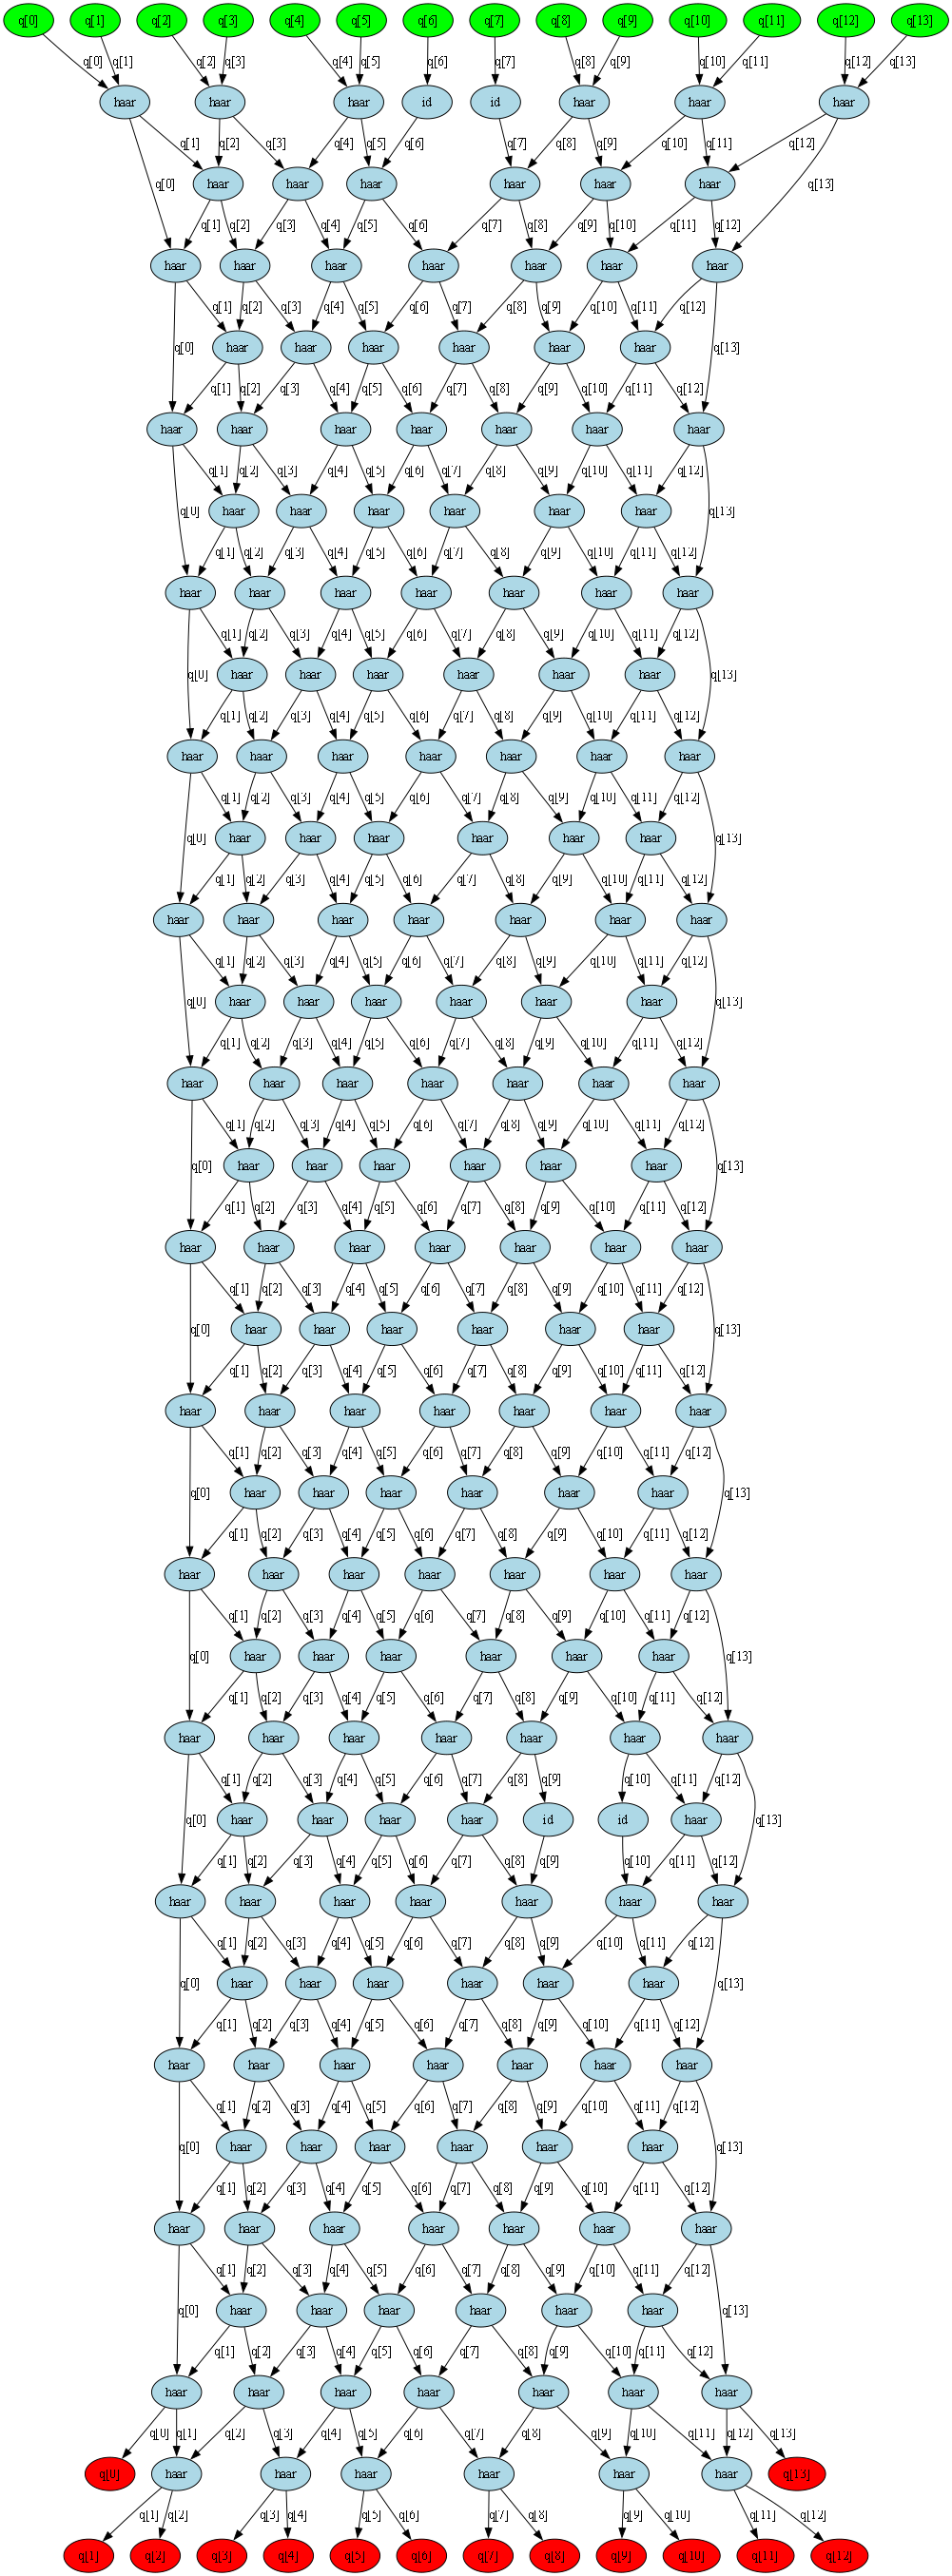

Saved figure to: C:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\qqe\notebooks\final\graph_haar_14q_30l.png


In [5]:
from IPython.display import display, Image as IPyImage
from PIL import Image as PILImage
from io import BytesIO

outdir = Path("final")
outdir.mkdir(parents=True, exist_ok=True)

outfile = outdir / f"graph_{family}_{n_qubits}q_{n_layers}l.png"

try:
    # Case 1: PIL image
    if isinstance(img, PILImage.Image):
        img_to_save = img.convert("RGB") if img.mode == "RGBA" else img
        img_to_save.save(outfile, format="PNG", dpi=(300, 300))
        display(img_to_save)

    # Case 2: Matplotlib figure
    elif hasattr(img, "savefig"):
        img.savefig(outfile, dpi=300, bbox_inches="tight")
        display(img)

    # Case 3: fallback, redraw as matplotlib
    else:
        fig = qc.draw(output="mpl")
        fig.savefig(outfile, dpi=300, bbox_inches="tight")
        display(fig)

    print(f"Saved figure to: {outfile.resolve()}")

except Exception as e:
    print(f"Could not save figure: {e}")

    try:
        bio = BytesIO()
        img.save(bio, format="PNG")
        display(IPyImage(data=bio.getvalue(), format="png"))
    except Exception:
        fig = qc.draw(output="mpl")
        display(fig)

In [6]:
fig = qc.draw(output="mpl", vertical_compression="low", fold=-1)
fig.savefig(f"final/circuit_{family}_{n_qubits}q_{n_layers}l.png", dpi=300, bbox_inches="tight")

# Résultats pour le calcul théorique brute sur 1 seul régime (identity-like et saturé)

In [7]:
from scripts.simulate_circuits import (
    sampling_config_identity_like,
    sampling_config_saturated,
)
from GNN.training.utils import collect_dataset_indices
from GNN.physics_aware_NN import ShardedQuantumCircuitGraphDataset

In [8]:
backend = "pennylane"
target = "SRE"
method = "fwht"
use_dask = True
regime_type = "saturated"
output_dir = f"notebooks/final/data/{regime_type}"
n_bins = 50
families = "haar,clifford"
n_seeds_train = 15
n_seeds_pred = 0
qubit_min, qubit_max = 4, 10
layer_min, layer_max = 2, 150
step = 2
target_qubits = "4,6,8,10"
max_shards = None
dask_workers = 4
dask_memory = "16GiB"

In [ ]:
generate_dataset(
    backend=backend,
    target=target,
    method=method,
    use_dask=use_dask,
    output_dir=output_dir,
    n_bins_option=n_bins,
    families=families,
    n_seeds_option=n_seeds_train,
    prediction_n_seeds_option=n_seeds_pred,
    qubits_min=qubit_min,
    qubits_max=qubit_max,
    qubits_step=step,
    layers_min=layer_min,
    layers_max=layer_max,
    layers_step=step,
    target_qubits=target_qubits,
    max_shards=max_shards,
    dask_n_workers=dask_workers,
    dask_memory_per_worker=dask_memory,
    block_size=10,
)

TypeError: main() got an unexpected keyword argument 'sampling_config'

In [ ]:
def dataset_to_dataframe(dataset):
    data = []
    keep_fields = ["n_qubits", "n_layers", "sre", "seed", "family"]
    for item in dataset:
        row = {}
        for field in keep_fields:
            if not hasattr(item, field):
                continue

            value = getattr(item, field)
            if field == "family":
                # Keep categorical label as text (e.g., "clifford")
                row[field] = str(value)
            else:
                row[field] = to_scalar(value)
        data.append(row)

    df = pd.DataFrame(data)

    int_cols = ["n_qubits", "n_layers", "seed"]
    for col in int_cols:
        if col in df.columns:
            df[col] = df[col].astype(int)

    float_cols = ["sre"]
    for col in float_cols:
        if col in df.columns:
            df[col] = df[col].astype(float)

    if "family" in df.columns:
        df["family"] = df["family"].astype(str)

    return df

In [ ]:
target_variant = "sre"
family = "quansistor"
# regime_type = "identity_like"
regime_type = "saturated"

index_path = collect_dataset_indices(
    f"../notebooks/final/data/{regime_type}",
    family=family,
)
print(f"Collected {len(index_path)} dataset indices for family '{family}' and regime '{regime_type}'")
base_dataset = ShardedQuantumCircuitGraphDataset(
    index_paths=index_path,
    target_variant=target_variant,
    split="all",
    cache_size=64,
)
df = dataset_to_dataframe(base_dataset)

plot_df = df[
    (df["sre"].notna())
]

avg_df = (
    plot_df
    .groupby(["n_qubits", "n_layers", "family"])
    .agg(
        sre_mean=("sre", "mean"),
        sre_std=("sre", "std"),
    )
    .reset_index()
)

avg_df.to_csv(f"final/data/avg_sre_{family}.csv", index=False)

Collected 1 dataset indices for family 'quansistor' and regime 'saturated'


N: 4 Upper Limit: 2.3225321769714355
N: 6 Upper Limit: 4.094251680374145
N: 8 Upper Limit: 6.026799615224203
N: 10 Upper Limit: 8.005779774983724


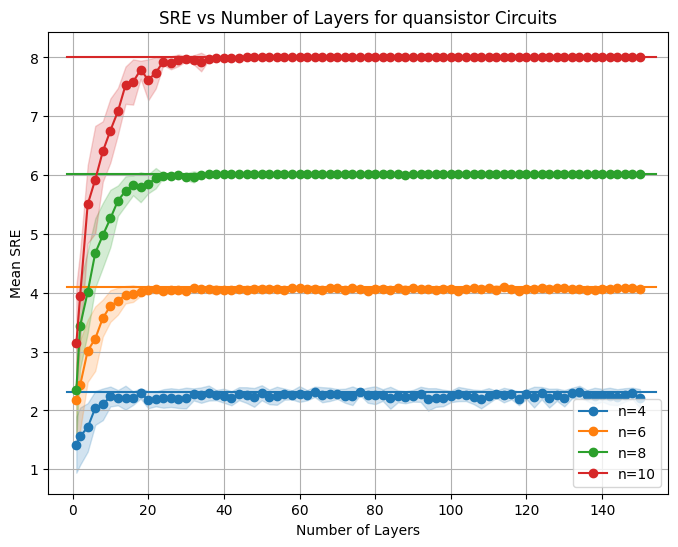

In [ ]:
plt.figure(figsize=(8, 6))
colours = {
    4: "tab:blue",
    6: "tab:orange",
    8: "tab:green",
    10: "tab:red",
}
for n in sorted(avg_df["n_qubits"].unique()):
    sub = avg_df[avg_df["n_qubits"] == n]

    plt.plot(
        sub["n_layers"],
        sub["sre_mean"],
        marker="o",
        linestyle="-",
        color=colours[n],
        label=f"n={n}",
    )
    plt.fill_between(
        sub["n_layers"],
        sub["sre_mean"] - sub["sre_std"],
        sub["sre_mean"] + sub["sre_std"],
        color=colours[n],
        alpha=0.2,
    )
    upper_lim =sub["sre_mean"].max() #n * np.log(2) # -np.log(1 / 2**n + 1 / 2**n)
    print("N:",n,"Upper Limit:",upper_lim)
    plt.axhline(upper_lim, xmin=0.03, xmax=0.98, linestyle="-", color=colours[n])

plt.title(f"SRE vs Number of Layers for {family} Circuits")
plt.xlabel("Number of Layers")
plt.ylabel("Mean SRE")
plt.legend()
plt.grid()
plt.savefig(f"../notebooks/final/figures/SRE/sre_vs_layers_{family}.png", dpi=300, bbox_inches="tight")
plt.show()

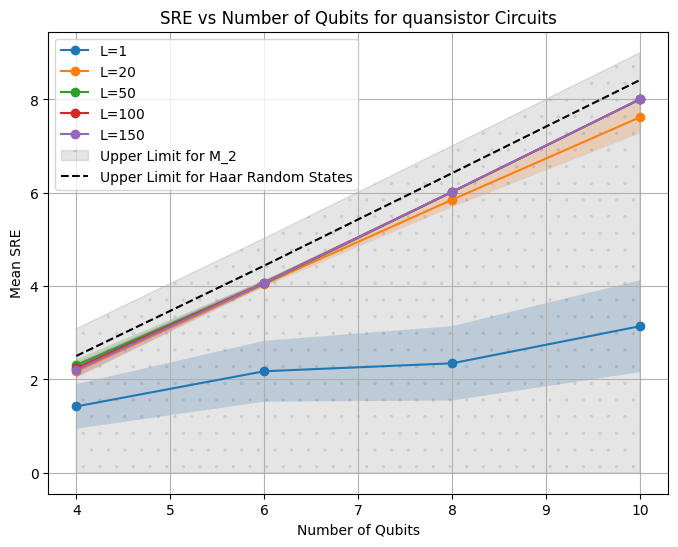

In [ ]:
plt.figure(figsize=(8, 6))
chosen_layers = [1, 20, 50, 100, 150]
for L in chosen_layers:
    sub = avg_df[avg_df["n_layers"] == L]
    plt.plot(
        sub["n_qubits"],
        sub["sre_mean"],
        marker="o",
        linestyle="-",
        label=f"L={L}",
    )
    plt.fill_between(
        sub["n_qubits"],
        sub["sre_mean"] - sub["sre_std"],
        sub["sre_mean"] + sub["sre_std"],
        alpha=0.2,
    )

nq = np.array([4, 6, 8, 10])
upper_lim = np.log2(2**nq + 1) - np.log2(2)  # Max SRE is log(2^n + 1) - log(2)
plt.fill_between(
    sub["n_qubits"],
    upper_lim,
    0,
    alpha=0.1,
    color="k",
    hatch=".",
    hatch_linewidth=0.05,
    label="Upper Limit for M_2",
)
haar_upper_lim = -np.log2(3 / (2**nq + 1))  # Upper limit for Haar random states
plt.plot(
    sub["n_qubits"],
    haar_upper_lim,
    linestyle="--",
    color="k",
    label="Upper Limit for Haar Random States",
)
plt.title(f"SRE vs Number of Qubits for {family} Circuits")
plt.xlabel("Number of Qubits")
plt.ylabel("Mean SRE")
plt.legend()
plt.grid()
plt.savefig(f"../notebooks/final/figures/SRE/sre_vs_qubits_{family}.png", dpi=300, bbox_inches="tight")
plt.show()

### Calcul du SRE pour n=12 qubits

In [4]:
from __future__ import annotations

import contextlib
import ctypes
import dataclasses
import gc
import hashlib
import itertools
import json
import logging
import os

from dataclasses import dataclass
from collections import defaultdict
from pathlib import Path
from typing import TYPE_CHECKING, Any, cast

import numpy as np
import torch
from torch_geometric.data import Data, InMemoryDataset

from tqdm import tqdm

from backend import PennylaneBackend, QuimbBackend
from circuit.families import (
    CliffordBrickwork,
    HaarBrickwork,
    QuansistorBrickwork,
    RandomCircuit,
)

# Keep this import path only if it is the correct one in your project.
# If your real function lives in circuit.matrix_factory, switch it there.
from circuit.gates import gate_unitary
from circuit.patterns import TdopingRules, to_qasm
from experiments.core import run_experiment
from GNN.encoder import eigenvalue_phase_histogram_features, qasm_to_pyg_graph
from utils import FileCache

from experiments.core import ExperimentConfig
from properties.compute import PropertyRequest
from states.types import BackendConfig

if TYPE_CHECKING:
    from circuit.spec import GateSpec


BACKEND_REGISTRY = {
    "pennylane": PennylaneBackend,
    "quimb": QuimbBackend,
}

FAMILY_REGISTRY = {
    "haar": HaarBrickwork,
    "clifford": CliffordBrickwork,
    "quansistor": QuansistorBrickwork,
    "random": RandomCircuit,
}

In [ ]:
family = "random"
n_qubits = 12
n_layers = 60
backend = "pennylane"
seed = np.random.randint(0, 10000)

img, qc, graph_data, gate_count, spec = simulate_circuit(
    family=family,
    n_qubits=n_qubits,
    n_layers=n_layers,
    backend=backend,
    seed=seed,
    regime_type="saturated", # identity_like, saturated
)

2026-06-12 10:42:04,258 - scripts.simulate_circuits - INFO - Simulating circuit family: random


In [ ]:
method = "fwht"
representation = "dense"
cache = FileCache(project_root / "outputs" / "cache")
property_requests = []
property_requests.append(PropertyRequest(name="SRE", method=method, params={}))

backend_config = BackendConfig(
    name=backend,
    representation=representation,
    params={},
)

exp_config = ExperimentConfig(
    spec=spec,
    backend=backend_config,
    properties=property_requests,
)

result = run_experiment(
    exp_config,
    backend_registry=BACKEND_REGISTRY,
    cache=cache,
)

In [ ]:
result.results

{'SRE:fwht': PropertyResult(name='SRE', value=np.float64(9.955925598672426), error=None, meta={'method': 'FWHT', 'n_qubits': 12, 'compute_time': 18.7737398147583})}

In [ ]:
sre_key = f"SRE:{method.lower()}"
sre = result.results.get(sre_key, None)
print(f"SRE: {float(sre.value) if sre is not None else 'N/A'}")

SRE: 9.955925598672426


In [ ]:
result = {
    "family": family,
    "n_qubits": n_qubits,
    "n_layers": n_layers,
    "method": method,
    "seed": seed,
    sre_key: float(sre.value) if sre is not None else None,
}

In [ ]:
output_file = Path("final/results.json")

# Load existing results
if output_file.exists():
    with open(output_file, "r") as f:
        results = json.load(f)
else:
    results = []

results.sort(
    key = lambda x: (x["family"], x["n_qubits"], x["n_layers"]),
)
# Add new result
results.append(result)

# Save updated list
with open(output_file, "w") as f:
    json.dump(results, f, indent=4)

In [ ]:
training_data_dir = "../outputs/data/datasets_SRE"
family = "random"
training_mode = "per_family"  # or "all_families"
family_filter = family if training_mode == "per_family" else None
method = "fwht"

In [14]:
train_paths = collect_dataset_indices(
    training_data_dir,
    family=family_filter,
)

print(f"Collected {len(train_paths)} training paths for family '{family}'.")

Collected 1 training paths for family 'random'.


In [15]:
train_paths

['C:\\Users\\Victor\\Desktop\\Université\\Research\\qml-quansistor-entropy\\qqe\\outputs\\data\\datasets_SRE\\random\\index_random.jsonl']

In [34]:
dataset = ShardedQuantumCircuitGraphDataset(
    index_paths=train_paths,
    target_variant="sre",
    split="prediction",
)

In [43]:
import numpy as np

def create_sample_rows(dataset, n_qubits: int, n_samples=20, seed=42):
    candidate_idx = [i for i in range(len(dataset)) if int(dataset[i].n_qubits) == n_qubits]
    np.random.default_rng(seed).shuffle(candidate_idx)

    rows = []
    for i in candidate_idx[:n_samples]:
        data = dataset[i]
        rows.append({
        "n_qubits": int(data.n_qubits),
        "n_layers": int(data.n_layers),
        "sre": float(data.sre) if getattr(data, "sre", None) is not None else None,
        "seed": int(data.seed),
        "family": str(data.family),
        "regime_type": str(data.regime) if hasattr(data, "regime") else None,
        })
    return rows

In [37]:
for row in rows:
    print(row)

{'n_qubits': 12, 'n_layers': 80, 'sre': nan, 'seed': 2081401163, 'family': 'random', 'regime_type': 'small_angles'}
{'n_qubits': 12, 'n_layers': 100, 'sre': nan, 'seed': 2435598678, 'family': 'random', 'regime_type': 'small_angles'}
{'n_qubits': 12, 'n_layers': 6, 'sre': nan, 'seed': 4051593307, 'family': 'random', 'regime_type': 'medium_angles'}
{'n_qubits': 12, 'n_layers': 1, 'sre': nan, 'seed': 58031564, 'family': 'random', 'regime_type': 'small_angles'}
{'n_qubits': 12, 'n_layers': 72, 'sre': nan, 'seed': 967017786, 'family': 'random', 'regime_type': 'small_angles'}
{'n_qubits': 12, 'n_layers': 86, 'sre': nan, 'seed': 957345244, 'family': 'random', 'regime_type': 'medium_angles'}
{'n_qubits': 12, 'n_layers': 44, 'sre': nan, 'seed': 61212769, 'family': 'random', 'regime_type': 'near_clifford'}
{'n_qubits': 12, 'n_layers': 12, 'sre': nan, 'seed': 523597942, 'family': 'random', 'regime_type': 'generic_dense'}
{'n_qubits': 12, 'n_layers': 48, 'sre': nan, 'seed': 1563831702, 'family': '

In [5]:
from GNN.dataset_builder import sample_generation_controls

from scripts.generate_dataset import default_sampling_config as sampling_config

In [53]:
def compute_SRE_from_dataset(
    dataset,
    n_qubits: int,
    global_seed: int,
    backend = "pennylane",
    representation = "dense",
):
    PROJECT_ROOT = Path().resolve().parent.parent.parent
    DATASET_DIR = PROJECT_ROOT / "outputs" / "gnn_graphs"
    DATASET_DIR.mkdir(parents=True, exist_ok=True)
    cache = FileCache(PROJECT_ROOT / "outputs" / "cache")

    logger.info(f"Computing SRE for {n_qubits} qubits with global seed {global_seed}...")
    rows = create_sample_rows(dataset, n_qubits=n_qubits, n_samples=20, seed=global_seed)

    logger.info(f"Computing SRE for {len(rows)} samples...")
    for row in rows:
        n_layers = int(row["n_layers"])
        n_qubits = int(row["n_qubits"])
        row_seed = int(row["seed"])
        family = str(row["family"])
        regime_type = str(row["regime_type"]) if row["regime_type"] is not None else "unknown"

        controls = sample_generation_controls(
            family=family,
            n_layers=n_layers,
            seed=row_seed,
            sampling_config=sampling_config(),
        )

        assert regime_type == controls["sampling_regime"], f"Regime type mismatch: {regime_type} vs {controls['regime_type']}"

        make_spec_kwargs = {
            "d": 2,
            "seed": row_seed,
        }

        if family == "clifford":
            make_spec_kwargs["tdoping"] = controls["tdoping"]

        elif family == "random":
            make_spec_kwargs["angle_regime"] = controls["angle_regime"]
            make_spec_kwargs["angle_scale"] = controls.get("angle_scale")
            make_spec_kwargs["gate_probability"] = controls["gate_probability"]

        elif family == "haar":
            make_spec_kwargs["gate_probability"] = controls["gate_probability"]
            make_spec_kwargs["haar_probability"] = controls["haar_probability"]
            make_spec_kwargs["haar_strength"] = controls["haar_strength"]
            make_spec_kwargs["haar_mode"] = controls["haar_mode"]

        elif family == "quansistor":
            make_spec_kwargs["param_regime"] = controls.get("sampling_regime")
            make_spec_kwargs["param_scale"] = controls.get("param_scale")
            make_spec_kwargs["gate_probability"] = controls.get("gate_probability")

        family_cls = FAMILY_REGISTRY[family]
        family_obj = family_cls()

        logger.info(f"Generating spec for {family} with n_qubits={n_qubits}, n_layers={n_layers}, seed={row_seed}...")
        spec = family_obj.make_spec(
            int(n_qubits),
            int(n_layers),
            **make_spec_kwargs,
        )

        property_requests = [PropertyRequest(name="SRE", method=method, params={})]

        backend_config = BackendConfig(
            name=backend,
            representation=representation,
            params={},
        )

        exp_config = ExperimentConfig(
            spec=spec,
            backend=backend_config,
            properties=property_requests,
        )

        logger.info(f"Computing SRE...")
        result = run_experiment(
            exp_config,
            backend_registry=BACKEND_REGISTRY,
            cache=cache,
        )
        logger.info(f"Done.")

        sre_key = f"SRE:{method.lower()}"
        sre_result = result.results.get(sre_key)
        sre_value = float(sre_result.value) if sre_result else None

        row["computed_sre"] = sre_value

    return rows

In [54]:
res = compute_SRE_from_dataset(dataset, n_qubits=12, global_seed=42)

2026-06-30 10:13:26,568 - __main__ - INFO - Computing SRE for 12 qubits with global seed 42...
2026-06-30 10:18:57,621 - __main__ - INFO - Computing SRE for 20 samples...
2026-06-30 10:18:57,623 - __main__ - INFO - Generating spec for random with n_qubits=12, n_layers=80, seed=2081401163...
2026-06-30 10:18:57,663 - __main__ - INFO - Computing SRE...
2026-06-30 10:19:27,253 - __main__ - INFO - Done.
2026-06-30 10:19:27,254 - __main__ - INFO - Generating spec for random with n_qubits=12, n_layers=100, seed=2435598678...
2026-06-30 10:19:27,308 - __main__ - INFO - Computing SRE...
2026-06-30 10:19:56,456 - __main__ - INFO - Done.
2026-06-30 10:19:56,458 - __main__ - INFO - Generating spec for random with n_qubits=12, n_layers=6, seed=4051593307...
2026-06-30 10:19:56,462 - __main__ - INFO - Computing SRE...
2026-06-30 10:20:26,907 - __main__ - INFO - Done.
2026-06-30 10:20:26,913 - __main__ - INFO - Generating spec for random with n_qubits=12, n_layers=1, seed=58031564...
2026-06-30 10:2

In [ ]:
PROJECT_ROOT = Path().resolve().parent.parent.parent
DATASET_DIR = PROJECT_ROOT / "outputs" / "gnn_graphs"
DATASET_DIR.mkdir(parents=True, exist_ok=True)
cache = FileCache(PROJECT_ROOT / "outputs" / "cache")

def compute_SRE_from_file(
    family: str,
    n_qubits: int,
    backend: str = "pennylane",
    method: str = "fwht",
    representation: str = "dense",
    n_samples: int = 20,
):
    df_pred = pd.read_csv(f"outputs/predictions/family/gnn_predictions_{family}.csv")
    df_pred = df_pred[df_pred["n_qubits"] == n_qubits]
    df_pred = df_pred.sample(n=n_samples, replace=False)

    rows = []
    for _, pred_row in df_pred.iterrows():
        row = {
            "n_qubits": pred_row["n_qubits"],
            "n_layers": pred_row["n_layers"],
            "seed": pred_row["seed"],
            "family": family,
            "regime_type": pred_row["regime"] if pd.notnull(pred_row["regime"]) else None,
            "predicted_sre": pred_row["predicted_sre"],
        }
        rows.append(row)
    
    for row in rows:
        n_layers = int(row["n_layers"])
        n_qubits = int(row["n_qubits"])
        row_seed = int(row["seed"])
        family = str(row["family"])
        regime_type = str(row["regime_type"]) if row["regime_type"] is not None else "unknown"

        controls = sample_generation_controls(
            family=family,
            n_layers=n_layers,
            seed=row_seed,
            sampling_config=sampling_config(),
        )

        assert regime_type == controls["sampling_regime"], f"Regime type mismatch: {regime_type} vs {controls['regime_type']}"

        make_spec_kwargs = {
            "d": 2, 
            "seed": row_seed,
        }

        if family == "clifford":
            make_spec_kwargs["tdoping"] = controls["tdoping"]

        elif family == "random":
            make_spec_kwargs["angle_regime"] = controls["angle_regime"]
            make_spec_kwargs["angle_scale"] = controls.get("angle_scale")
            make_spec_kwargs["gate_probability"] = controls["gate_probability"]

        elif family == "haar":
            make_spec_kwargs["gate_probability"] = controls["gate_probability"]
            make_spec_kwargs["haar_probability"] = controls["haar_probability"]
            make_spec_kwargs["haar_strength"] = controls["haar_strength"]
            make_spec_kwargs["haar_mode"] = controls["haar_mode"]

        elif family == "quansistor":
            make_spec_kwargs["param_regime"] = controls.get("sampling_regime")
            make_spec_kwargs["param_scale"] = controls.get("param_scale")
            make_spec_kwargs["gate_probability"] = controls.get("gate_probability")

        family_cls = FAMILY_REGISTRY[family]
        family_obj = family_cls()

        logger.info(f"Generating spec for {family} with n_qubits={n_qubits}, n_layers={n_layers}, seed={row_seed}...")
        spec = family_obj.make_spec(
            int(n_qubits),
            int(n_layers),
            **make_spec_kwargs,
        )

        property_requests = [PropertyRequest(name="SRE", method=method, params={})]

        backend_config = BackendConfig(
            name=backend,
            representation=representation,
            params={},
        )

        exp_config = ExperimentConfig(
            spec=spec,
            backend=backend_config,
            properties=property_requests,
        )

        logger.info(f"Computing SRE...")
        result = run_experiment(
            exp_config,
            backend_registry=BACKEND_REGISTRY,
            cache=cache,
        )
        logger.info(f"Done.")

        sre_key = f"SRE:{method.lower()}"
        sre_result = result.results.get(sre_key)
        sre_value = float(sre_result.value) if sre_result else None

        row["computed_sre"] = sre_value
        row["error"] = abs(sre_value - row["predicted_sre"]) if sre_value is not None else None
    
    return rows


In [11]:
family = "random"
backend = "pennylane"
method = "fwht"
representation = "dense"
n_qubits = 12
n_samples = 20

random = compute_SRE_from_file(family="random", backend=backend, method=method, representation=representation, n_qubits=n_qubits, n_samples=n_samples)
haar = compute_SRE_from_file(family="haar", backend=backend, method=method, representation=representation, n_qubits=n_qubits, n_samples=n_samples)
clifford = compute_SRE_from_file(family="clifford", backend=backend, method=method, representation=representation, n_qubits=n_qubits, n_samples=n_samples)
quansistor = compute_SRE_from_file(family="quansistor", backend=backend, method=method, representation=representation, n_qubits=n_qubits, n_samples=n_samples)

2026-07-01 12:00:13,811 - __main__ - INFO - Generating spec for random with n_qubits=12, n_layers=94, seed=2643060866...
2026-07-01 12:00:14,037 - __main__ - INFO - Computing SRE...
2026-07-01 12:00:33,115 - __main__ - INFO - Done.
2026-07-01 12:00:33,115 - __main__ - INFO - Generating spec for random with n_qubits=12, n_layers=40, seed=1556620177...
2026-07-01 12:00:33,129 - __main__ - INFO - Computing SRE...
2026-07-01 12:00:52,404 - __main__ - INFO - Done.
2026-07-01 12:00:52,405 - __main__ - INFO - Generating spec for random with n_qubits=12, n_layers=8, seed=3515191269...
2026-07-01 12:00:52,408 - __main__ - INFO - Computing SRE...
2026-07-01 12:01:11,699 - __main__ - INFO - Done.
2026-07-01 12:01:11,701 - __main__ - INFO - Generating spec for random with n_qubits=12, n_layers=70, seed=4225565760...
2026-07-01 12:01:11,723 - __main__ - INFO - Computing SRE...
2026-07-01 12:01:32,899 - __main__ - INFO - Done.
2026-07-01 12:01:32,900 - __main__ - INFO - Generating spec for random wi

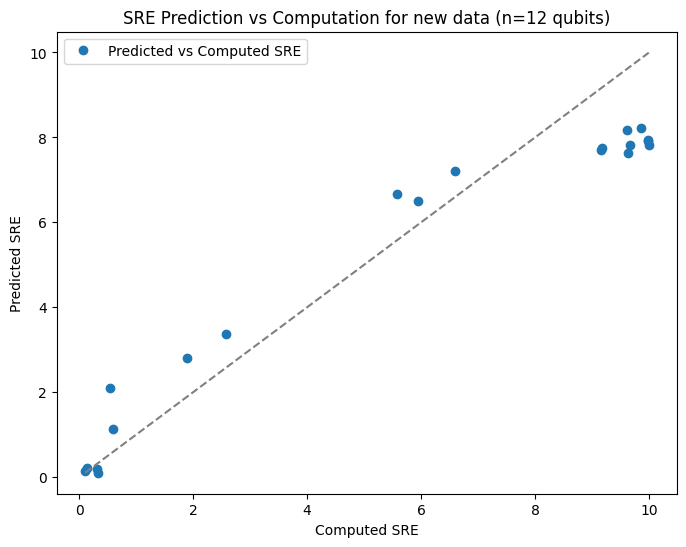

In [12]:
pred_sre = [row["predicted_sre"] for row in random]
target_sre = [row["computed_sre"] for row in random]

plt.figure(figsize=(8, 6))
plt.plot(target_sre, pred_sre, marker="o", linestyle="", label="Predicted vs Computed SRE")
plt.plot([min(target_sre), max(target_sre)], [min(target_sre), max(target_sre)], linestyle="--", color="gray")
plt.xlabel("Computed SRE")
plt.ylabel("Predicted SRE")
plt.title("SRE Prediction vs Computation for new data (n=12 qubits)")
plt.legend()
plt.show()

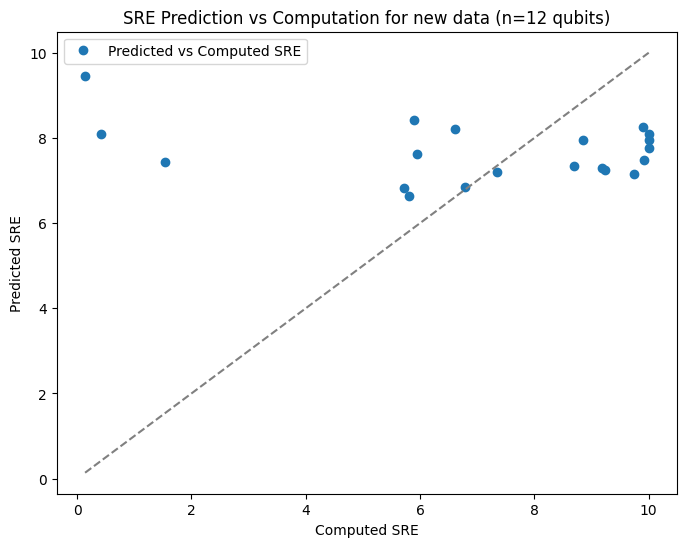

In [13]:
pred_sre = [row["predicted_sre"] for row in haar]
target_sre = [row["computed_sre"] for row in haar]

plt.figure(figsize=(8, 6))
plt.plot(target_sre, pred_sre, marker="o", linestyle="", label="Predicted vs Computed SRE")
plt.plot([min(target_sre), max(target_sre)], [min(target_sre), max(target_sre)], linestyle="--", color="gray")
plt.xlabel("Computed SRE")
plt.ylabel("Predicted SRE")
plt.title("SRE Prediction vs Computation for new data (n=12 qubits)")
plt.legend()
plt.show()

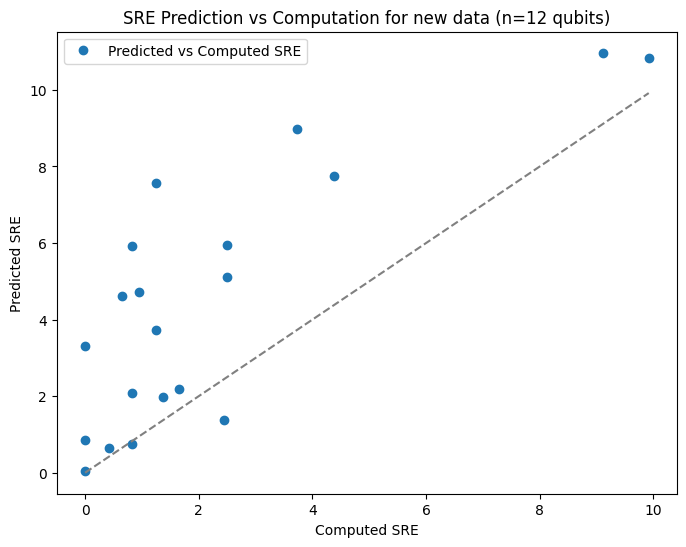

In [14]:
pred_sre = [row["predicted_sre"] for row in clifford]
target_sre = [row["computed_sre"] for row in clifford]

plt.figure(figsize=(8, 6))
plt.plot(target_sre, pred_sre, marker="o", linestyle="", label="Predicted vs Computed SRE")
plt.plot([min(target_sre), max(target_sre)], [min(target_sre), max(target_sre)], linestyle="--", color="gray")
plt.xlabel("Computed SRE")
plt.ylabel("Predicted SRE")
plt.title("SRE Prediction vs Computation for new data (n=12 qubits)")
plt.legend()
plt.show()

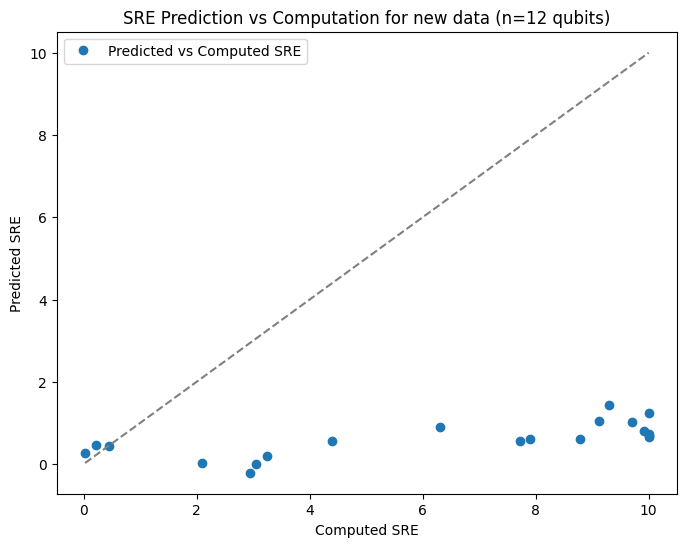

In [15]:
pred_sre = [row["predicted_sre"] for row in quansistor]
target_sre = [row["computed_sre"] for row in quansistor]

plt.figure(figsize=(8, 6))
plt.plot(target_sre, pred_sre, marker="o", linestyle="", label="Predicted vs Computed SRE")
plt.plot([min(target_sre), max(target_sre)], [min(target_sre), max(target_sre)], linestyle="--", color="gray")
plt.xlabel("Computed SRE")
plt.ylabel("Predicted SRE")
plt.title("SRE Prediction vs Computation for new data (n=12 qubits)")
plt.legend()
plt.show()

In [16]:
random = pd.DataFrame(random)
haar = pd.DataFrame(haar)
clifford = pd.DataFrame(clifford)
quansistor = pd.DataFrame(quansistor)

In [17]:
random.to_csv(f"final/predictions/random_sre_comparison_{n_qubits}q.csv", index=False)
haar.to_csv(f"final/predictions/haar_sre_comparison_{n_qubits}q.csv", index=False)
clifford.to_csv(f"final/predictions/clifford_sre_comparison_{n_qubits}q.csv", index=False)
quansistor.to_csv(f"final/predictions/quansistor_sre_comparison_{n_qubits}q.csv", index=False)

# Prédictions

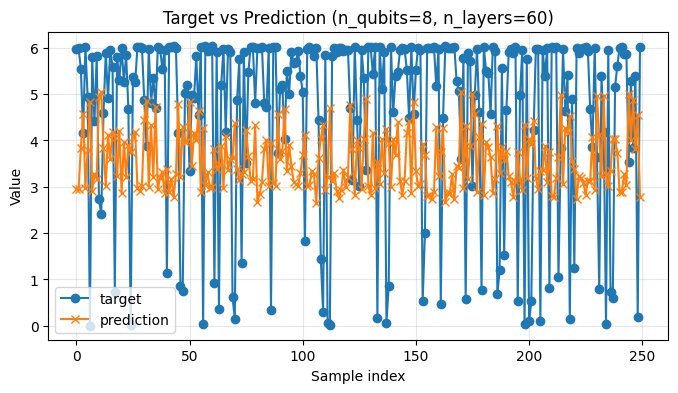

Pearson r = -0.5162


Text(0.5, 1.0, 'True vs Predicted SRE for Haar Family (GNN Model)')

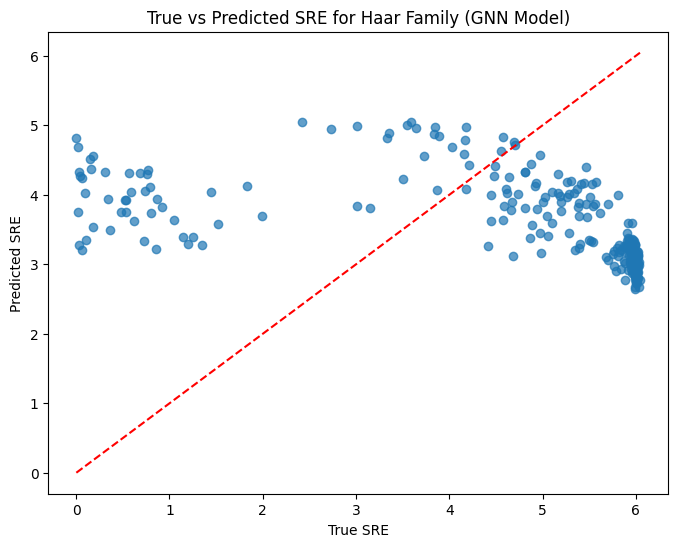

In [7]:
df = pd.read_csv(f"final/predictions/gnn_predictions_random.csv")
plot_qubits = 8
plot_layers = 60
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)

nq=plot_qubits
nl=plot_layers
# df["prediction"] = df["prediction"] * nq
view_correlation(
    df,
    nq=plot_qubits,
    nl=plot_layers,
    col_x="target_SRE",
    col_y="predicted_SRE",
)
df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
plt.figure(figsize=(8, 6))
plt.scatter(df["target_SRE"], df["predicted_SRE"], alpha=0.7)
plt.plot([df["target_SRE"].min(), df["target_SRE"].max()], [df["target_SRE"].min(), df["target_SRE"].max()], "r--")  # y=x line
plt.xlabel("True SRE")
plt.ylabel("Predicted SRE")
plt.title("True vs Predicted SRE for Haar Family (GNN Model)")

In [1]:
import qutip as qt
b = qt.Bloch3d()

AttributeError: module 'qutip' has no attribute 'Bloch3d'

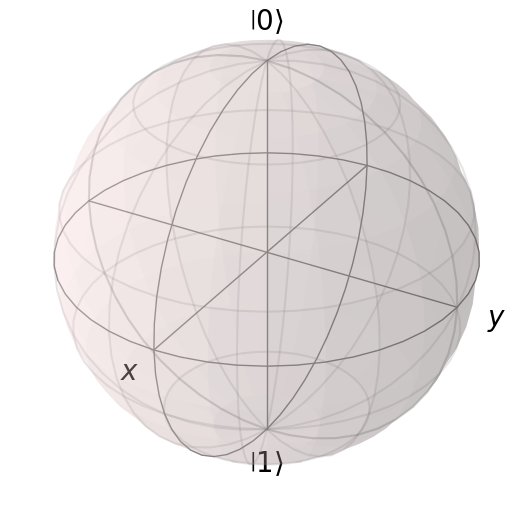

In [69]:
b.show()

In [73]:
qt.Bloch3d()

AttributeError: module 'qutip' has no attribute 'Bloch3d'

Text(0.5, 0.92, '3D Sphere')

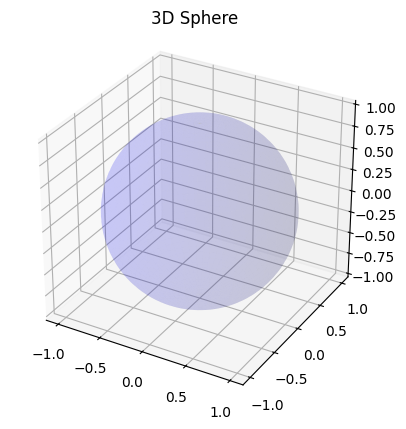

In [60]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)

x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(x, y, z, color='b', alpha=0.1)
ax.set_aspect('equal')
ax.set_title("3D Sphere")

In [74]:
PARAMS = {
    "random" : {
        "lr" : 0.0009860340204413903,
        "batch_size" : 128,
        "model_hparams": {
            "gnn_hidden" : 64,
            "gnn_heads": 2,
            "global_hidden": 32,
            "reg_hidden": 128,
            "num_layers": 6,
            "dropout_rate": 0.06640302989664926,
        },
        "train_params": {
            "weight_decay": 3.0500428108369453e-05,
            "grad_clip": 4.379744711312854,
            "early_stopping_patience": 15,
            "early_stopping_min_delta": 0.0,
            "num_workers": 0,
        },
    },
    "clifford" : {
        "lr" : 2.5223176427539664e-05,
        "batch_size" : 32,
        "model_hparams": {
            "gnn_hidden" : 128,
            "gnn_heads": 2,
            "global_hidden": 16,
            "reg_hidden": 32,
            "num_layers": 6,
            "dropout_rate": 0.014842423657881243,
        },
        "train_params": {
            "weight_decay": 1.560010639264171e-05,
            "grad_clip": 7.2440146231033875,
            "early_stopping_patience": 15,
            "early_stopping_min_delta": 0.0,
            "num_workers": 0,
        },
    },
    "haar" : {
        "lr" : 0.0005456850011484297,
        "batch_size" : 16,
        "model_hparams": {
            "gnn_hidden" : 64,
            "gnn_heads": 2,
            "global_hidden": 128,
            "reg_hidden": 16,
            "num_layers": 2,
            "dropout_rate": 0.004127592869557634,
        },
        "train_params": {
            "weight_decay": 1.0439900428164368e-05,
            "grad_clip":  0.011242628935673588,
            "early_stopping_patience": 15,
            "early_stopping_min_delta": 0.0,
            "num_workers": 0,
        },
    },
    "quansistor" : {
        "lr" : 0.0005456850011484297,
        "batch_size" : 16,
        "model_hparams": {
            "gnn_hidden" : 64,
            "gnn_heads": 2,
            "global_hidden": 128,
            "reg_hidden": 16,
            "num_layers": 2,
            "dropout_rate": 0.004127592869557634,
        },
        "train_params": {
            "weight_decay": 1.0439900428164368e-05,
            "grad_clip":  0.011242628935673588,
            "early_stopping_patience": 15,
            "early_stopping_min_delta": 0.0,
            "num_workers": 0,
        },
    },
}

In [87]:
family = "haar"
lr = 1.5131621801102364e-05

In [88]:
model_hparams = PARAMS.get(family, {}).get("model_hparams", {})
train_hparams = PARAMS.get(family, {}).get("train_hparams", {})
lr = PARAMS.get(family, {}).get("lr", lr)
batch_size = PARAMS.get(family, {}).get("batch_size", 0)

In [89]:
lr

0.0005456850011484297

## Exemple circuit

In [5]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

In [26]:
dev = qml.device("default.qubit", wires=[0, 1, 2])


@qml.qnode(dev)
def my_circuit(x, y):
    qml.CNOT(wires=[0,1])
    qml.H(wires=0)
    qml.RX(x, wires=0)
    qml.RY(y, wires=1)
    qml.CNOT(wires=[1,2])
    return qml.state()

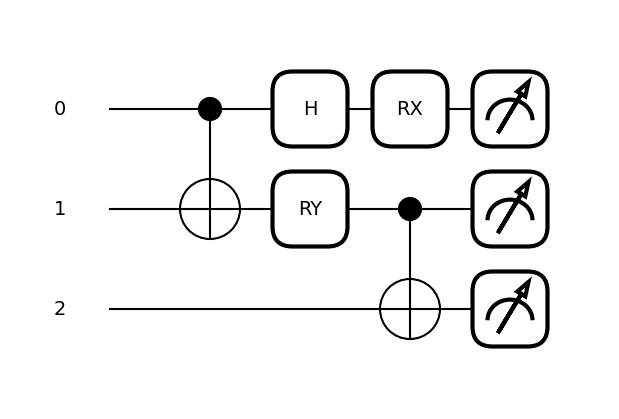

In [30]:
_ = qml.draw_mpl(my_circuit, level="device")(np.pi/4, np.pi/3)

### Predictions Graphs

In [43]:
family = "quansistor"

In [44]:
df_random = pd.read_csv(f"outputs/predictions/family/gnn_predictions_{family}.csv")

plot_df_random = df_random[
    (df_random["predicted_sre"].notna())
]
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    plot_df_random[col] = plot_df_random[col].apply(to_scalar).astype(int)
avg_df_random = (
    plot_df_random
    .groupby(["n_qubits", "n_layers", "family"])
    .agg(
        sre_mean=("predicted_sre", "mean"),
        sre_std=("predicted_sre", "std"),
    )
    .reset_index()
)

avg_df_random.to_csv(f"final/data/avg_sre_pred_{family}.csv", index=False)

N: 12 Upper Limit: 1.1547872170380185
N: 14 Upper Limit: 1.4820451819896698
N: 16 Upper Limit: 1.6373450258799962
N: 18 Upper Limit: 1.9202447608964783
N: 20 Upper Limit: 2.208417344944818


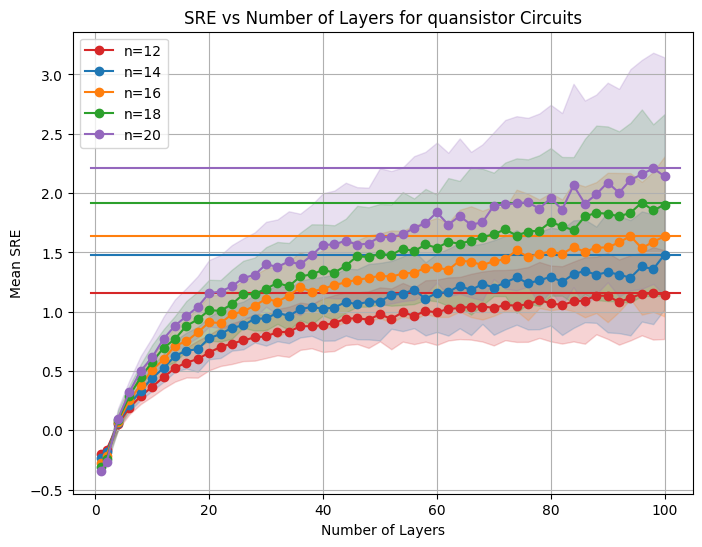

In [45]:
plt.figure(figsize=(8, 6))
colours = {
    14: "tab:blue",
    16: "tab:orange",
    18: "tab:green",
    12: "tab:red",
    20: "tab:purple",
}

avg_df_random = avg_df_random[avg_df_random["n_qubits"].isin([12, 14, 16, 18, 20])]

for n in sorted(avg_df_random["n_qubits"].unique()):
    sub = avg_df_random[avg_df_random["n_qubits"] == n]

    plt.plot(
        sub["n_layers"],
        sub["sre_mean"],
        marker="o",
        linestyle="-",
        color=colours[n],
        label=f"n={n}",
    )
    plt.fill_between(
        sub["n_layers"],
        sub["sre_mean"] - sub["sre_std"],
        sub["sre_mean"] + sub["sre_std"],
        color=colours[n],
        alpha=0.2,
    )
    upper_lim =sub["sre_mean"].max() #n * np.log(2) # -np.log(1 / 2**n + 1 / 2**n)
    print("N:",n,"Upper Limit:",upper_lim)
    plt.axhline(upper_lim, xmin=0.03, xmax=0.98, linestyle="-", color=colours[n])

plt.title(f"SRE vs Number of Layers for {family} Circuits")
plt.xlabel("Number of Layers")
plt.ylabel("Mean SRE")
plt.legend()
plt.grid()
#plt.savefig(f"../notebooks/final/figures/SRE/sre_vs_layers_{family}.png", dpi=300, bbox_inches="tight")
plt.show()

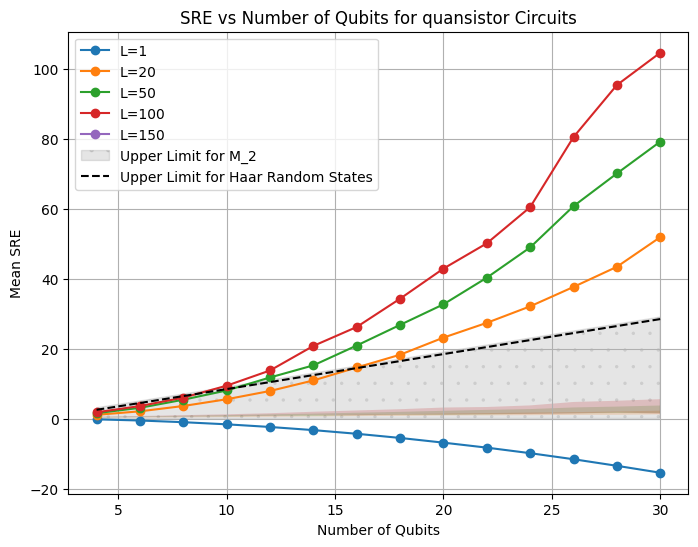

In [ ]:
avg_df_random = (
    plot_df_random
    .groupby(["n_qubits", "n_layers", "family"])
    .agg(
        sre_mean=("predicted_sre", "mean"),
        sre_std=("predicted_sre", "std"),
    )
    .reset_index()
)

plt.figure(figsize=(8, 6))
chosen_layers = [1, 20, 50, 100, 150]
for L in chosen_layers:
    sub = avg_df_random[avg_df_random["n_layers"] == L]
    plt.plot(
        sub["n_qubits"],
        sub["sre_mean"],
        marker="o",
        linestyle="-",
        label=f"L={L}",
    )
    plt.fill_between(
        sub["n_qubits"],
        sub["sre_mean"] - sub["sre_std"],
        sub["sre_mean"] + sub["sre_std"],
        alpha=0.2,
    )

nq = np.array([4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30])
upper_lim = np.log2(2**nq + 1) - np.log2(2)  # Max SRE is log(2^n + 1) - log(2)
plt.fill_between(
    nq,
    upper_lim,
    0,
    alpha=0.1,
    color="k",
    hatch=".",
    hatch_linewidth=0.05,
    label="Upper Limit for M_2",
)
haar_upper_lim = -np.log2(3 / (2**nq + 1))  # Upper limit for Haar random states
plt.plot(
    nq,
    haar_upper_lim,
    linestyle="--",
    color="k",
    label="Upper Limit for Haar Random States",
)
plt.title(f"SRE vs Number of Qubits for {family} Circuits")
plt.xlabel("Number of Qubits")
plt.ylabel("Mean SRE")
plt.legend()
plt.grid()
# plt.savefig(f"../notebooks/final/figures/SRE/sre_vs_qubits_{family}.png", dpi=300, bbox_inches="tight")
plt.show()